In [42]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为SimHei
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

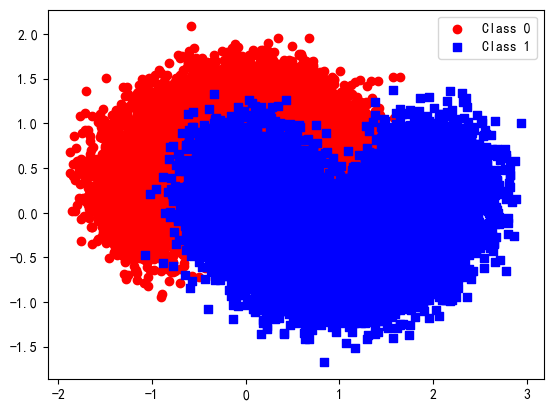

In [18]:
x, y = make_moons(n_samples=50000, noise=0.3, random_state=42)

plt.scatter(x[y == 0, 0], x[y == 0, 1], c='red', marker='o', label='Class 0')
plt.scatter(x[y == 1, 0], x[y == 1, 1], c='blue', marker='s', label='Class 1')
plt.legend()
plt.show()


In [19]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [23]:
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)
print("Logistic Regression Accuracy:", log_reg.score(x_test, y_test))

Logistic Regression Accuracy: 0.8535


In [24]:
svc = SVC()
svc.fit(x_train, y_train)
print("SVM Accuracy:", svc.score(x_test, y_test))

SVM Accuracy: 0.9123


In [25]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(x_train, y_train)
print("Decision Tree Accuracy:", decision_tree.score(x_test, y_test))

Decision Tree Accuracy: 0.8738


In [ ]:
# 集成学习
# 1. 投票法
# 2. 随机森林 #
# 3. 梯度提升树

# bagging 并行方法，每个基学习器独立训练，最终结果通过投票或平均等方式进行组合。
# boosting 串行方法，每个基学习器依次训练，每个基学习器的训练都依赖于前一个基学习器的结果，最终结果通过加权投票或加权平均等方式进行组合。

In [ ]:
# 手动投票法
y_pred_log_reg = log_reg.predict(x_test)
y_pred_svc = svc.predict(x_test)
y_pred_decision_tree = decision_tree.predict(x_test)

y_pred = np.array((y_pred_log_reg + y_pred_svc +
                  y_pred_decision_tree) >= 2, dtype=int)

print("手动投票法准确率:", accuracy_score(y_test, y_pred))

手动投票法准确率: 0.9038


In [34]:
# 1. 投票法
# 票法是一种简单的集成学习方法，通过结合多个不同的模型来提高预测性能。
# 每个模型对输入数据进行预测，然后通过投票机制（多数投票或加权投票）来决定最终的预测结果。
# 这种方法可以减少单个模型的偏差和方差，从而提高整体的准确率和鲁棒性。

# 参数说明：
# - estimators: 一个列表，包含要组合的模型，每个元素是一个元组，格式为 (名称, 模型实例)。
# - voting: 投票方式，'hard' 表示多数投票，'soft' 表示加权投票（需要模型支持概率预测）。
voting_clf = VotingClassifier(
    estimators=[('log_reg', LogisticRegression()), ('svc', SVC()),
                ('decision_tree', DecisionTreeClassifier())],
    voting='hard'  # 'hard'表示多数投票，'soft'表示加权投票
)

voting_clf.fit(x_train, y_train)
print("Voting Classifier Accuracy:", voting_clf.score(x_test, y_test))

Voting Classifier Accuracy: 0.9047


In [ ]:
# bagging 减小方差 
# 只能选择一个模型，随机森林是bagging的一个特例。

# 参数说明：
# - estimator: 基学习器，指定要使用的模型类型。
# - n_estimators: 基学习器的数量，即要训练的模型个数。
# - max_samples: 每个基学习器训练时使用的样本比例，可以是整数（样本数量）或浮点数（样本比例）。
# - oob_score: 是否使用袋外样本评估模型性能。
# - bootstrap: 是否有放回抽样，即每个基学习器训练时是否允许重复使用样本。
# - n_jobs: 使用所有可用的CPU核心进行训练。
# - max_features: 每个基学习器使用的特征比例，可以是整数（特征数量）或浮点数（特征比例）。
# - bootstrap_features: 是否对特征进行有放回抽样，即每个基学习器训练时是否允许重复使用特征。
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=50000,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1,
    max_features=1.0,
    bootstrap_features=False
)

bagging.fit(x_train, y_train)
print("Bagging Classifier Accuracy:", bagging.score(x_test, y_test))

# 随机森林是一个特殊的bagging方法，基学习器必须是决策树。
# 并且在训练过程中引入了更多的随机性（随机选择特征和样本），从而进一步提高了模型的泛化能力和鲁棒性。

Bagging Classifier Accuracy: 0.9


In [ ]:
# boosting 减小偏差
# AdaBoost（Adaptive Boosting）是一种常用的提升方法.
# 通过逐步训练一系列弱学习器（通常是决策树），每个学习器都试图纠正前一个学习器的错误，从而提高整体模型的性能。
# AdaBoost通过调整样本权重来关注难以分类的样本，使得后续的学习器更关注这些样本，从而提高模型的准确率和鲁棒性。

# 参数说明：
# - estimator: 基学习器，指定要使用的模型类型。
# - n_estimators: 基学习器的数量，即要训练的模型个数。
ada_boost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500
)

ada_boost.fit(x_train, y_train)
print("AdaBoost Classifier Accuracy:", ada_boost.score(x_test, y_test))

AdaBoost Classifier Accuracy: 0.8748


In [ ]:
# GDBT（Gradient Boosting Decision Tree）是一种提升方法，通过逐步训练一系列弱学习器（通常是决策树）。
# 每个学习器都试图纠正前一个学习器的残差，从而提高整体模型的性能。
# GDBT通过优化损失函数来训练模型，使得每个学习器都能更好地拟合数据，从而提高模型的准确率和鲁棒性。
# 模型是通过梯度下降的方式来优化损失函数的，因此被称为梯度提升树（Gradient Boosting Decision Tree）。

# 参数说明：
# - n_estimators: 基学习器的数量，即要训练的模型个数。
# - learning_rate: 学习率，控制每个基学习器对最终模型的贡献程度。
# - max_depth: 决策树的最大深度。

gdbt = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gdbt.fit(x_train, y_train)
print("Gradient Boosting Classifier Accuracy:", gdbt.score(x_test, y_test))

Gradient Boosting Classifier Accuracy: 0.9103
